# 05 — SD3 Medium time-adaptive SAE circuits

In [1]:
from pathlib import Path
import os
import sys
import json
import math
import subprocess

import numpy as np
import pandas as pd
from IPython.display import display


def _looks_like_repo(path: Path) -> bool:
    return (path / "src" / "diffusion_attention_analysis_v2").exists() and (path / "configs").exists()


def _find_project_root() -> Path:
    candidates = []
    if os.environ.get("PROJECT_ROOT"):
        candidates.append(Path(os.environ["PROJECT_ROOT"]))
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.extend([
        Path("/home/jupyter/project/diffusion_attention_analysis_2"),
        Path("/home/jupyter/datasphere/project/diffusion_attention_analysis_2"),
    ])
    for candidate in candidates:
        if _looks_like_repo(candidate.expanduser().resolve()):
            return candidate.expanduser().resolve()
    raise FileNotFoundError("Cannot locate diffusion_attention_analysis_2 repository. Set PROJECT_ROOT manually.")


PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
os.environ["PYTHONPATH"] = str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", "")

from diffusion_attention_analysis_v2.notebook_runner import run_config, show_report
from diffusion_attention_analysis_v2.sd3_notebook_utils import (
    activation_inventory,
    attention_inventory,
    collect_intervention_diffs,
    directory_size_bytes,
    estimate_sd3_storage,
    feature_specificity,
    find_project_root,
    gib,
    make_image_grid,
    prepare_datashere_storage,
    safe_file_part,
    select_features_for_labels,
    write_label_probe_prompts,
    write_sd3_circuit_prompts,
)

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("Python =", sys.executable)
print("cwd =", Path.cwd())


PROJECT_ROOT = /home/jupyter/project/diffusion_attention_analysis_2
Python = /usr/local/bin/python3
cwd = /home/jupyter/project/diffusion_attention_analysis_2


In [2]:
from pathlib import Path
from datetime import datetime
import importlib

PROJECT_ROOT = Path(PROJECT_ROOT)

backup_dir = PROJECT_ROOT / ".path_placeholders_backup"
backup_dir.mkdir(parents=True, exist_ok=True)

for name in ["outputs", "annotations"]:
    p = PROJECT_ROOT / name

    if p.exists() or p.is_symlink():
        if not p.is_dir():
            backup = backup_dir / f"{name}.{datetime.now().strftime('%Y%m%d_%H%M%S')}"
            print(f"Moving legacy placeholder: {p} -> {backup}")
            p.rename(backup)

    p.mkdir(parents=True, exist_ok=True)
    print(f"OK: {p} is now a directory")

import diffusion_attention_analysis_v2.sd3_notebook_utils as sd3_utils
importlib.reload(sd3_utils)

from diffusion_attention_analysis_v2.sd3_notebook_utils import (
    estimate_sd3_storage,
    prepare_datashere_storage,
)

OK: /home/jupyter/project/diffusion_attention_analysis_2/outputs is now a directory
OK: /home/jupyter/project/diffusion_attention_analysis_2/annotations is now a directory


## 0. Path management: container4 and cache layout


In [3]:
RUN_TAG = "sd3_medium_sae_circuit_150"
CONTAINER_NAME = "container4"

storage_estimate = estimate_sd3_storage(prompt_count=150)
storage_info = prepare_datashere_storage(
    project_root=PROJECT_ROOT,
    run_tag=RUN_TAG,
    container_name=CONTAINER_NAME,
    require_container=True,
    min_free_gb=storage_estimate["recommended_container4_gib_rounded"],
)

non_tensor_artifacts = (
    storage_estimate["artifacts_without_model_or_pip_gib"]
    - storage_estimate["residual_stream_total_gib"]
    - storage_estimate["full_joint_probability_maps_head_averaged_total_gib"]
)

estimate_rows = [
    {"component": "Full SD3 joint-attention maps, head-averaged, 1350 files", "GiB": storage_estimate["full_joint_probability_maps_head_averaged_total_gib"]},
    {"component": "Residual activations for SAE, 1350 files", "GiB": storage_estimate["residual_stream_total_gib"]},
    {"component": "Images + masks + reports + SAE checkpoints", "GiB": non_tensor_artifacts},
    {"component": "HF/model cache budget", "GiB": storage_estimate["model_cache_gib_budget"]},
    {"component": "pip cache budget", "GiB": storage_estimate["pip_cache_gib_budget"]},
    {"component": "safety margin", "GiB": storage_estimate["safety_margin_gib"]},
    {"component": "recommended minimum", "GiB": storage_estimate["recommended_container4_gib"]},
    {"component": "rounded minimum", "GiB": storage_estimate["recommended_container4_gib_rounded"]},
    {"component": "practical DataSphere allocation", "GiB": max(240.0, float(storage_estimate["recommended_container4_gib_rounded"]))},
]

display(pd.DataFrame(estimate_rows))
display(pd.DataFrame([storage_info]))

print("Full SD3 joint probability maps:")
print("  head-averaged per file GiB:", round(storage_estimate["full_joint_probability_maps_head_averaged_per_file_gib"], 4))
print("  head-averaged total GiB:", round(storage_estimate["full_joint_probability_maps_head_averaged_total_gib"], 2))
print("  headwise total GiB, not enabled:", round(storage_estimate["full_joint_probability_maps_headwise_total_gib"], 2))
print("Chosen artifacts:", storage_estimate["primary_artifact_choice"])

if not storage_info["free_space_ok"]:
    print("WARNING: free space is below the rounded minimum. Increase container4 or reduce prompt_count/modules/steps.")


,component,GiB
0,"Full SD3 joint-attention maps, head-averaged, ...",98.651854
1,"Residual activations for SAE, 1350 files",31.640625
2,Images + masks + reports + SAE checkpoints,1.913867
3,HF/model cache budget,32.000000
4,pip cache budget,8.000000
5,safety margin,45.000000
6,recommended minimum,217.206346
7,rounded minimum,220.000000
8,practical DataSphere allocation,240.000000


,project_root,container,run_tag,output_run_root,annotation_run_root,tmp_root,pip_cache_dir,hf_home,free_gb,min_free_gb,free_space_ok
0,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/filestore/container4,sd3_medium_sae_circuit_150,/home/jupyter/filestore/container4/diffusion_a...,/home/jupyter/filestore/container4/diffusion_a...,/home/jupyter/filestore/container4/tmp/sd3_med...,/home/jupyter/filestore/container4/pip_cache,/home/jupyter/filestore/container4/hf_home,91.881428,220.0,False


Full SD3 joint probability maps:
  head-averaged per file GiB: 0.0731
  head-averaged total GiB: 98.65
  headwise total GiB, not enabled: 2367.64
Chosen artifacts: full SD3 joint-attention probability maps + image-token residual updates


## 1. Experiment constants and run switches


In [4]:
PROMPTS_PATH = PROJECT_ROOT / "prompts" / "sd3_medium_sae_circuit_150.jsonl"
CAPTURE_DIR = PROJECT_ROOT / "outputs" / RUN_TAG / "01_capture"
DIAG_DIR = PROJECT_ROOT / "outputs" / RUN_TAG / "02_attention_localization"
MASK_DIR = PROJECT_ROOT / "annotations" / RUN_TAG
SAE_ROOT = PROJECT_ROOT / "outputs" / RUN_TAG / "03_sae"
CONCEPT_ROOT = PROJECT_ROOT / "outputs" / RUN_TAG / "04_concept_dictionary"
INTERVENTION_ROOT = PROJECT_ROOT / "outputs" / RUN_TAG / "05_interventions"
PROBE_PROMPT_ROOT = PROJECT_ROOT / "prompts" / f"{RUN_TAG}_probes"

CAPTURE_STEPS = [0, 13, 27]
TRANSFORMER_MODULES = ["transformer_blocks.0", "transformer_blocks.11", "transformer_blocks.23"]
ATTENTION_LAYERS = ["transformer_blocks.0.attn.processor", "transformer_blocks.11.attn.processor", "transformer_blocks.23.attn.processor"]

SAE_SPECS = {
    "early_block0_step0": {"layer": "transformer_blocks.0", "step": 0, "window": [0, 1, 2, 3, 4]},
    "mid_block11_step13": {"layer": "transformer_blocks.11", "step": 13, "window": [11, 12, 13, 14, 15]},
    "late_block23_step27": {"layer": "transformer_blocks.23", "step": 27, "window": [23, 24, 25, 26, 27]},
}

TARGET_LABELS = ["dog", "cat", "car", "book", "bicycle", "person"]
PROMPTS_PER_LABEL = 2

DRY_RUN_FIRST = True
RUN_CAPTURE = True
RUN_MASKS = True
RUN_DIAGNOSTICS = True
RUN_SAE_TRAINING = True
RUN_CONCEPT_DICTIONARY = True
RUN_BLOCK_SCALING = True
RUN_SAE_STEERING = True

print("RUN_TAG:", RUN_TAG)
print("Expected activation files:", 150 * len(CAPTURE_STEPS) * len(TRANSFORMER_MODULES))
print("PROMPTS_PATH:", PROMPTS_PATH)
print("CAPTURE_DIR:", CAPTURE_DIR)


RUN_TAG: sd3_medium_sae_circuit_150
Expected activation files: 1350
PROMPTS_PATH: /home/jupyter/project/diffusion_attention_analysis_2/prompts/sd3_medium_sae_circuit_150.jsonl
CAPTURE_DIR: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/01_capture


In [5]:
DRY_RUN_FIRST = False
RUN_CAPTURE = False
RUN_MASKS = False
RUN_DIAGNOSTICS = False
RUN_SAE_TRAINING = False
RUN_CONCEPT_DICTIONARY = False
RUN_BLOCK_SCALING = False
RUN_SAE_STEERING = False

In [8]:
from huggingface_hub import login
login(token="")


## 2. Generate deterministic SD3 prompt set

The prompt file has 150 prompts, 30 object labels, and two object entities per prompt. Each label appears approximately evenly across the dataset.


In [9]:
write_sd3_circuit_prompts(PROMPTS_PATH, n=150, force=True)
rows = [json.loads(line) for line in PROMPTS_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
label_counts = {}
for row in rows:
    for entity in row.get("entities", []):
        label_counts[entity["label"]] = label_counts.get(entity["label"], 0) + 1

print("prompts:", len(rows))
display(pd.DataFrame(sorted(label_counts.items()), columns=["label", "count"]).head(30))
display(pd.DataFrame(rows).head(5))


prompts: 150


,label,count
0,apple,10
1,backpack,10
2,banana,10
3,bed,10
4,bench,10
5,bicycle,10
6,bird,10
7,boat,10
8,book,10
9,bridge,10


,id,prompt,target_word,entities
0,sd3_circuit_000_dog_table,realistic photo of a dog next to a table insid...,dog,"[{'label': 'dog', 'token': 'dog'}, {'label': '..."
1,sd3_circuit_001_cat_umbrella,documentary photo of a cat near a umbrella ins...,cat,"[{'label': 'cat', 'token': 'cat'}, {'label': '..."
2,sd3_circuit_002_car_lamp,studio photo of a car beside a lamp inside a b...,car,"[{'label': 'car', 'token': 'car'}, {'label': '..."
3,sd3_circuit_003_book_car,natural light photo of a book under a car insi...,book,"[{'label': 'book', 'token': 'book'}, {'label':..."
4,sd3_circuit_004_cup_flower,clear detailed photo of a cup in front of a fl...,cup,"[{'label': 'cup', 'token': 'cup'}, {'label': '..."


In [6]:
if not PROMPTS_PATH.exists():
    write_sd3_circuit_prompts(PROMPTS_PATH, n=150, force=True)
else:
    print("Prompt file already exists:", PROMPTS_PATH)

rows = [json.loads(line) for line in PROMPTS_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
print("prompts:", len(rows))
display(pd.DataFrame(rows).head(5))

Prompt file already exists: /home/jupyter/project/diffusion_attention_analysis_2/prompts/sd3_medium_sae_circuit_150.jsonl
prompts: 150


,id,prompt,target_word,entities
0,sd3_circuit_000_dog_table,realistic photo of a dog next to a table insid...,dog,"[{'label': 'dog', 'token': 'dog'}, {'label': '..."
1,sd3_circuit_001_cat_umbrella,documentary photo of a cat near a umbrella ins...,cat,"[{'label': 'cat', 'token': 'cat'}, {'label': '..."
2,sd3_circuit_002_car_lamp,studio photo of a car beside a lamp inside a b...,car,"[{'label': 'car', 'token': 'car'}, {'label': '..."
3,sd3_circuit_003_book_car,natural light photo of a book under a car insi...,book,"[{'label': 'book', 'token': 'book'}, {'label':..."
4,sd3_circuit_004_cup_flower,clear detailed photo of a cup in front of a fl...,cup,"[{'label': 'cup', 'token': 'cup'}, {'label': '..."


## 3. Stage 1–2: capture, masks, probability-map localization

Capture uses `track_step_on_denoiser_pre_hook=True`, `strict_activation_count=True` and `strict_attention_count=True`, so the previous `1347 vs 1350` issue becomes visible immediately instead of silently propagating. The expected counts are 1350 residual activation files and 1350 full joint-attention probability-map files.


In [ ]:
CAPTURE_CFG = "configs/01_capture/sd3_medium_sae_circuit_150.yaml"
MASK_CFG = "configs/02_attention_localization/sd3_medium_sae_circuit_masks_clipseg.yaml"
DIAG_CFG = "configs/02_attention_localization/sd3_medium_sae_circuit_diagnostics.yaml"

if DRY_RUN_FIRST:
    run_config(CAPTURE_CFG, dry_run=True)
if RUN_CAPTURE:
    capture_report = run_config(CAPTURE_CFG, dry_run=False)
else:
    capture_report = show_report(str(CAPTURE_DIR / "report.json"))

if DRY_RUN_FIRST:
    run_config(MASK_CFG, dry_run=True)
if RUN_MASKS:
    mask_report = run_config(MASK_CFG, dry_run=False)
else:
    mask_report = show_report(str(MASK_DIR / "report.json"))

if DRY_RUN_FIRST:
    run_config(DIAG_CFG, dry_run=True)
if RUN_DIAGNOSTICS:
    diag_report = run_config(DIAG_CFG, dry_run=False)
else:
    diag_report = show_report(str(DIAG_DIR / "report.json"))


## 4. Artifact count audit

For 150 prompts, 3 steps and 3 selected blocks/layers the expected count is 1350 activation files and 1350 attention probability-map files. This cell verifies the actual files on disk and shows missing combinations if any.


In [11]:
act_inv = activation_inventory(CAPTURE_DIR / "captures", TRANSFORMER_MODULES, CAPTURE_STEPS)
attn_inv = attention_inventory(CAPTURE_DIR / "captures", ATTENTION_LAYERS, CAPTURE_STEPS)

print("activation samples:", act_inv["samples"])
print("activation expected:", act_inv["expected"], "actual:", act_inv["actual"], "missing:", len(act_inv["missing"]))
if act_inv["missing"]:
    display(pd.DataFrame(act_inv["missing"]).head(20))
assert act_inv["actual"] == act_inv["expected"], f"Activation count mismatch: {act_inv['actual']} != {act_inv['expected']}"

print("attention samples:", attn_inv["samples"])
print("attention expected:", attn_inv["expected"], "actual:", attn_inv["actual"], "missing:", len(attn_inv["missing"]))
if attn_inv["missing"]:
    display(pd.DataFrame(attn_inv["missing"]).head(20))
assert attn_inv["actual"] == attn_inv["expected"], f"Attention count mismatch: {attn_inv['actual']} != {attn_inv['expected']}"

summary_path = DIAG_DIR / "sd3_joint_attention_localization_by_layer_step.csv"
if summary_path.exists():
    loc_df = pd.read_csv(summary_path)
    display(loc_df)


activation samples: 150
activation expected: 1350 actual: 1350 missing: 0
attention samples: 150
attention expected: 1350 actual: 1350 missing: 0


,layer,step,iou,centroid_distance,entropy
0,transformer_blocks.0.attn.processor,0,0.139704,15.775850,0.989595
1,transformer_blocks.0.attn.processor,13,0.176970,15.699307,0.991116
2,transformer_blocks.0.attn.processor,27,0.170755,15.999631,0.989020
3,transformer_blocks.11.attn.processor,0,0.252095,11.767849,0.906075
4,transformer_blocks.11.attn.processor,13,0.315533,7.131822,0.816263
5,transformer_blocks.11.attn.processor,27,0.158436,9.965264,0.870771
6,transformer_blocks.23.attn.processor,0,0.257466,12.786139,0.975776
7,transformer_blocks.23.attn.processor,13,0.246596,11.202113,0.934592
8,transformer_blocks.23.attn.processor,27,0.240204,12.513282,0.946239


## 5. Stage 3: train time-adaptive SAEs

We train three separate Top-K SAEs, one per time/layer role:

- early layout: `transformer_blocks.0`, step 0;
- mid semantic/object: `transformer_blocks.11`, step 13;
- late texture/detail: `transformer_blocks.23`, step 27.


In [12]:
SAE_CFG = "configs/03_sae_training/sd3_medium_sae_circuit_base.yaml"
sae_reports = []
for name, spec in SAE_SPECS.items():
    out_dir = SAE_ROOT / name
    overrides = [
        f"sae.layer={spec['layer']}",
        f"sae.step={spec['step']}",
        f"data.output_dir={out_dir}",
        "sae.max_activation_files=150",
        "sae.max_tokens_per_file=2048",
    ]
    print(f"\n=== SAE {name}: {spec['layer']} step {spec['step']} ===")
    if DRY_RUN_FIRST:
        run_config(SAE_CFG, overrides=overrides, dry_run=True)
    if RUN_SAE_TRAINING:
        report = run_config(SAE_CFG, overrides=overrides, dry_run=False)
    else:
        report = show_report(str(out_dir / "report.json")) or {}
    sae_reports.append({"sae_name": name, **spec, **(report or {})})

display(pd.DataFrame([{k: v for k, v in r.items() if k not in {"history", "metadata"}} for r in sae_reports]))



=== SAE early_block0_step0: transformer_blocks.0 step 0 ===
$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/03_sae_training/sd3_medium_sae_circuit_base.yaml --dry-run --override sae.layer=transformer_blocks.0 --override sae.step=0 --override data.output_dir=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae/early_block0_step0 --override sae.max_activation_files=150 --override sae.max_tokens_per_file=2048


dry-run sae_training plan:   0%|          | 0/1 [00:00<?, ?it/s]

dry-run complete


<ml_kernel._vendor.IPython.core.display.JSON object>

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/03_sae_training/sd3_medium_sae_circuit_base.yaml --override sae.layer=transformer_blocks.0 --override sae.step=0 --override data.output_dir=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae/early_block0_step0 --override sae.max_activation_files=150 --override sae.max_tokens_per_file=2048


...

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/03_sae_training/sd3_medium_sae_circuit_base.yaml --override sae.layer=transformer_blocks.23 --override sae.step=27 --override data.output_dir=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae/late_block23_step27 --override sae.max_activation_files=150 --override sae.max_tokens_per_file=2048


SAE training started:   0%|          | 0/1 [00:00<?, ?it/s]

SAE epoch completed {'stage_id': '03_sae_training_sd3_medium_sae_circuit_base', 'time_sec': 57.605, 'total': 1, 'current': 1, 'epoch': 0, 'mean_loss': 300.1603315734863, 'mean_reconstruction_loss': 300.1603315734863, 'active_fraction': 0.005208333333333333, 'batches': 150}
SAE training finished


<ml_kernel._vendor.IPython.core.display.JSON object>

,sae_name,layer,step,window,status,checkpoint
0,early_block0_step0,transformer_blocks.0,0,"[0, 1, 2, 3, 4]",ok,/home/jupyter/project/diffusion_attention_anal...
1,mid_block11_step13,transformer_blocks.11,13,"[11, 12, 13, 14, 15]",ok,/home/jupyter/project/diffusion_attention_anal...
2,late_block23_step27,transformer_blocks.23,27,"[23, 24, 25, 26, 27]",ok,/home/jupyter/project/diffusion_attention_anal...


## 6. Stage 4: build mask-aligned concept dictionaries

Each dictionary ranks SAE features by inside-vs-outside activation contrast under CLIPSeg object masks. The feature specificity audit penalizes features reused across many labels.


In [13]:
CONCEPT_CFG = "configs/04_concept_dictionary/sd3_medium_sae_circuit_base.yaml"
concept_reports = []
for name, spec in SAE_SPECS.items():
    sae_path = SAE_ROOT / name / "sae.pt"
    out_dir = CONCEPT_ROOT / name
    overrides = [
        f"dictionary.layer={spec['layer']}",
        f"dictionary.step={spec['step']}",
        f"data.sae_checkpoint={sae_path}",
        f"data.output_dir={out_dir}",
        "dictionary.max_activation_files=150",
    ]
    print(f"\n=== Concept dictionary {name} ===")
    if DRY_RUN_FIRST:
        run_config(CONCEPT_CFG, overrides=overrides, dry_run=True)
    if RUN_CONCEPT_DICTIONARY:
        report = run_config(CONCEPT_CFG, overrides=overrides, dry_run=False)
    else:
        report = show_report(str(out_dir / "report.json")) or {}
    concept_reports.append({"sae_name": name, **spec, **(report or {})})

display(pd.DataFrame(concept_reports))

selection = {}
for name in SAE_SPECS:
    csv_path = CONCEPT_ROOT / name / "concept_dictionary.csv"
    if csv_path.exists():
        spec_df = feature_specificity(csv_path)
        display(spec_df.sort_values("specificity_score", ascending=False).head(12))
        selection[name] = select_features_for_labels(csv_path, TARGET_LABELS, per_label=4, max_reuse=12, min_score=0.0)

print(json.dumps(selection, indent=2, ensure_ascii=False))



=== Concept dictionary early_block0_step0 ===
$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/04_concept_dictionary/sd3_medium_sae_circuit_base.yaml --dry-run --override dictionary.layer=transformer_blocks.0 --override dictionary.step=0 --override data.sae_checkpoint=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae/early_block0_step0/sae.pt --override data.output_dir=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/04_concept_dictionary/early_block0_step0 --override dictionary.max_activation_files=150


dry-run concept_dictionary plan:   0%|          | 0/1 [00:00<?, ?it/s]

dry-run complete


<ml_kernel._vendor.IPython.core.display.JSON object>

$ /usr/local/bin/python3 -m diffusion_attention_analysis_v2.cli.run_stage --config configs/04_concept_dictionary/sd3_medium_sae_circuit_base.yaml --override dictionary.layer=transformer_blocks.0 --override dictionary.step=0 --override data.sae_checkpoint=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae/early_block0_step0/sae.pt --override data.output_dir=/home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/04_concept_dictionary/early_block0_step0 --override dictionary.max_activation_files=150


...

,sae_name,layer,step,window,status,labels,rows
0,early_block0_step0,transformer_blocks.0,0,"[0, 1, 2, 3, 4]",ok,30,600
1,mid_block11_step13,transformer_blocks.11,13,"[11, 12, 13, 14, 15]",ok,30,600
2,late_block23_step27,transformer_blocks.23,27,"[23, 24, 25, 26, 27]",ok,30,600


,label,count,feature_id,score,reuse_count,label_rank,specificity_score
504,bed,10,1616,4.560566,1,5,4.560566
242,window,10,586,3.820689,1,3,3.820689
512,bed,10,1680,3.570248,1,13,3.570248
101,lamp,10,1839,6.269162,3,2,3.134581
248,window,10,2512,2.595152,1,9,2.595152
560,newspaper,10,114,10.583437,17,1,2.538040
516,bed,10,1602,2.522735,1,17,2.522735
241,window,10,322,3.933434,2,2,2.481720
100,lamp,10,2077,8.217825,9,1,2.473812
60,umbrella,10,2145,6.362445,5,1,2.461330


,label,count,feature_id,score,reuse_count,label_rank,specificity_score
240,window,10,258,16.118120,4,1,6.941697
440,apple,10,547,29.721212,26,1,6.250666
247,window,10,420,8.791214,2,8,5.546638
501,bed,10,2205,14.237927,5,2,5.507982
512,bed,10,1086,8.578375,2,13,5.412352
40,cat,10,547,25.557444,26,1,5.374984
245,window,10,84,10.704632,3,6,5.352316
242,window,10,2456,12.318902,4,3,5.305462
500,bed,10,1323,23.201931,20,1,5.282389
522,bus,10,1881,16.724583,9,3,5.034601


,label,count,feature_id,score,reuse_count,label_rank,specificity_score
260,tree,10,2346,140.400787,14,1,35.936708
261,tree,10,1823,107.032547,21,2,24.001388
440,apple,10,949,79.585464,11,1,22.199804
40,cat,10,1823,97.067368,21,1,21.766758
262,tree,10,2656,91.936356,20,3,20.931173
500,bed,10,1449,69.621895,10,1,20.125241
263,tree,10,1395,89.415199,23,4,19.501839
220,bicycle,10,1823,86.339600,21,1,19.361122
264,tree,10,2463,84.457764,22,5,18.670633
41,cat,10,2656,80.399490,20,2,18.304572


{
  "early_block0_step0": {
    "dog": [
      1722,
      73,
      2776,
      1320
    ],
    "cat": [
      1722,
      471,
      2776,
      1638
    ],
    "car": [
      2965,
      2358,
      735,
      1420
    ],
    "book": [
      589,
      1761,
      73,
      2189
    ],
    "bicycle": [
      2985,
      2189,
      1773,
      862
    ],
    "person": [
      336,
      1320,
      807,
      2011
    ]
  },
  "mid_block11_step13": {
    "dog": [
      1877,
      572
    ],
    "cat": [
      572,
      1920
    ],
    "car": [
      2814,
      1881,
      536,
      697
    ],
    "book": [
      961,
      1918,
      2205,
      1877
    ],
    "bicycle": [
      697,
      2563,
      366,
      1767
    ],
    "person": [
      2814,
      697,
      1098
    ]
  },
  "late_block23_step27": {
    "dog": [
      949
    ],
    "cat": [
      949
    ],
    "car": [
      1449,
      2015,
      2615,
      1453
    ],
    "book": [
      1337,
      1449
    ]

## 7. Stage 5a: time-window block residual scaling

This is the causal baseline: before interpreting SAE features, verify that the selected residual stream actually affects generation in the corresponding denoising window.


In [ ]:
BLOCK_CFG = "configs/05_interventions/sd3_medium_time_adaptive_block_scaling.yaml"
block_reports = []
for name, spec in SAE_SPECS.items():
    out_dir = INTERVENTION_ROOT / "block_scaling" / name
    overrides = [
        f"data.output_dir={out_dir}",
        "data.max_prompts=4",
        f"intervention.modules=[{spec['layer']}]",
        f"intervention.target_steps={spec['window']}",
        "intervention.scales=[0.60, 0.75, 1.15, 1.35]",
    ]
    print(f"\n=== Block scaling {name}: {spec['layer']} steps={spec['window']} ===")
    if DRY_RUN_FIRST:
        run_config(BLOCK_CFG, overrides=overrides, dry_run=True)
    if RUN_BLOCK_SCALING:
        report = run_config(BLOCK_CFG, overrides=overrides, dry_run=False)
    else:
        report = show_report(str(out_dir / "report.json")) or {}
    block_reports.append({"sae_name": name, "out_dir": str(out_dir), **spec, **(report or {})})

display(pd.DataFrame(block_reports))


## 8. Stage 5b: active-token SAE steering

For each time/layer SAE and each target label, we select specificity-aware concept IDs and run active-token steering. Active-token mode modifies only the spatial image tokens where selected features already activate.


In [ ]:
SAE_STEER_CFG = "configs/05_interventions/sd3_medium_time_adaptive_sae_steering.yaml"
probe_paths = write_label_probe_prompts(PROMPTS_PATH, PROBE_PROMPT_ROOT, TARGET_LABELS, prompts_per_label=PROMPTS_PER_LABEL)
print(json.dumps(probe_paths, indent=2, ensure_ascii=False))

sae_steer_reports = []
for name, spec in SAE_SPECS.items():
    sae_path = SAE_ROOT / name / "sae.pt"
    label_to_ids = selection.get(name, {})
    for label in TARGET_LABELS:
        concept_ids = label_to_ids.get(label, [])
        prompt_path = probe_paths.get(label)
        if not concept_ids or not prompt_path:
            print(f"[skip] {name}/{label}: concept_ids={concept_ids}, prompt_path={prompt_path}")
            continue
        out_dir = INTERVENTION_ROOT / "sae_steering" / name / safe_file_part(label)
        overrides = [
            f"data.prompts_path={prompt_path}",
            f"data.sae_checkpoint={sae_path}",
            f"data.output_dir={out_dir}",
            f"data.max_prompts={PROMPTS_PER_LABEL}",
            f"intervention.module={spec['layer']}",
            f"intervention.target_steps={spec['window']}",
            f"intervention.concept_ids={concept_ids}",
            "intervention.betas=[-40.0, 0.0, 40.0, 60.0]",
            "intervention.branch_mode=cond",
            "intervention.direction_mode=mean_decoder_direction",
            "intervention.spatial_mode=active_tokens",
            "intervention.active_quantile=0.85",
            "intervention.outside_scale=0.0",
            "intervention.normalize_direction=rms",
            "intervention.beta_scale_mode=activation_rms",
        ]
        print(f"\n=== SAE steering {name}/{label}: ids={concept_ids} ===")
        if DRY_RUN_FIRST:
            run_config(SAE_STEER_CFG, overrides=overrides, dry_run=True)
        if RUN_SAE_STEERING:
            report = run_config(SAE_STEER_CFG, overrides=overrides, dry_run=False)
        else:
            report = show_report(str(out_dir / "report.json")) or {}
        sae_steer_reports.append({"sae_name": name, "label": label, "concept_ids": concept_ids, "out_dir": str(out_dir), **spec, **(report or {})})

display(pd.DataFrame(sae_steer_reports))


## 9. Collect diff metrics

Metrics compare each same-seed intervention image with the baseline image from Stage 1. They are not a semantic success metric; they quantify whether a causal intervention changed the image and how strongly.


In [16]:
diff_tables = []
baseline_samples = CAPTURE_DIR / "samples"

for name, spec in SAE_SPECS.items():
    stage_dir = INTERVENTION_ROOT / "block_scaling" / name
    diff_tables.append(collect_intervention_diffs(
        stage_dir,
        baseline_samples,
        image_name="ablation.png",
        kind="block_scaling",
        extra={"sae_name": name, "window": name},
    ))

for name in SAE_SPECS:
    for label in TARGET_LABELS:
        stage_dir = INTERVENTION_ROOT / "sae_steering" / name / safe_file_part(label)
        diff_tables.append(collect_intervention_diffs(
            stage_dir,
            baseline_samples,
            image_name="steered.png",
            kind="sae_steering",
            extra={"sae_name": name, "window": name, "label": label},
        ))

diff_df = pd.concat([d for d in diff_tables if d is not None and not d.empty], ignore_index=True) if any(d is not None and not d.empty for d in diff_tables) else pd.DataFrame()
if not diff_df.empty:
    diff_df["artifact_flag"] = (diff_df["l1_mean"] > 0.35) | (diff_df["changed_px_020"] > 0.70)
    diff_df["moderate_change"] = diff_df["l1_mean"].between(0.03, 0.30) & (~diff_df["artifact_flag"])
    out_csv = INTERVENTION_ROOT / "sd3_time_adaptive_diff_metrics.csv"
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    diff_df.to_csv(out_csv, index=False)
    display(diff_df.head(20))
    summary = diff_df.groupby(["kind", "window"], as_index=False).agg(
        n=("sample_id", "count"),
        mean_l1=("l1_mean", "mean"),
        median_l1=("l1_mean", "median"),
        changed_px_020=("changed_px_020", "mean"),
        artifact_rate=("artifact_flag", "mean"),
        moderate_rate=("moderate_change", "mean"),
    )
    display(summary)
else:
    print("No diff metrics collected yet. Run interventions first.")


,kind,sample_id,base_id,prompt,baseline_path,edited_path,beta,scale,concept_ids,module,sae_name,window,l1_mean,rmse,changed_px_005,changed_px_010,changed_px_020,label,artifact_flag,moderate_change
0,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_0.6,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.60,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.261939,0.335220,0.903549,0.772888,0.518967,NaN,False,True
1,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_0.75,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.75,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.316425,0.397657,0.950745,0.858444,0.646439,NaN,False,False
2,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_1.15,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.15,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.128323,0.203915,0.581467,0.419479,0.205490,NaN,False,True
3,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_1.35,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.35,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.155710,0.217828,0.692169,0.533646,0.296707,NaN,False,True
4,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_0.6,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.60,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.337169,0.393341,0.981262,0.932220,0.797882,NaN,True,False
5,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_0.75,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.75,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.404804,0.514242,0.968307,0.918625,0.803024,NaN,True,False
6,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_1.15,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.15,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.177244,0.253846,0.818146,0.675537,0.297607,NaN,False,True
7,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_1.35,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.35,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.202779,0.286138,0.838638,0.708572,0.374054,NaN,False,True
8,block_scaling,sd3_circuit_002_car_lamp_seed_0000_scale_0.6,sd3_circuit_002_car_lamp_seed_0000,studio photo of a car beside a lamp inside a b...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.60,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.222027,0.284881,0.842270,0.679794,0.451019,NaN,False,True
9,block_scaling,sd3_circuit_002_car_lamp_seed_0000_scale_0.75,sd3_circuit_002_car_lamp_seed_0000,studio photo of a car beside a lamp inside a b...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.75,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.329946,0.403671,0.978271,0.944519,0.741943,

,kind,window,n,mean_l1,median_l1,changed_px_020,artifact_rate,moderate_rate
0,block_scaling,early_block0_step0,16,0.252012,0.254185,0.514531,0.1875,0.687500
1,block_scaling,late_block23_step27,16,0.000458,0.000462,0.000000,0.0000,0.000000
2,block_scaling,mid_block11_step13,16,0.031079,0.025238,0.013493,0.0000,0.500000
3,sae_steering,early_block0_step0,48,0.272002,0.338557,0.563177,0.6250,0.020833
4,sae_steering,late_block23_step27,48,0.196754,0.182393,0.389232,0.2500,0.395833
5,sae_steering,mid_block11_step13,48,0.257722,0.307453,0.500447,0.3750,0.208333


## 10. Visualizations


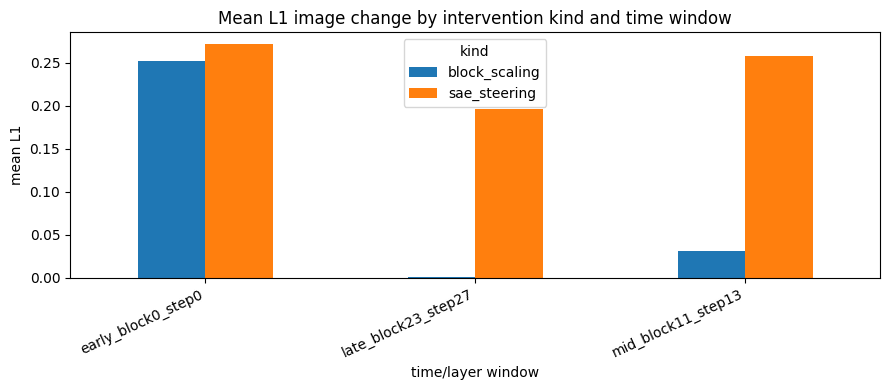

,kind,window,label,beta,scale,l1_mean,changed_px_020,artifact_flag,prompt
106,sae_steering,mid_block11_step13,cat,40.0,NaN,0.486721,0.810074,True,documentary photo of a cat near a umbrella ins...
107,sae_steering,mid_block11_step13,cat,60.0,NaN,0.486014,0.813309,True,documentary photo of a cat near a umbrella ins...
92,sae_steering,early_block0_step0,person,-40.0,NaN,0.451504,0.821198,True,natural light photo of a window behind a perso...
140,sae_steering,mid_block11_step13,person,-40.0,NaN,0.446199,0.751266,True,natural light photo of a window behind a perso...
136,sae_steering,mid_block11_step13,person,-40.0,NaN,0.433016,0.831100,True,studio photo of a person in front of a apple o...
88,sae_steering,early_block0_step0,person,-40.0,NaN,0.431507,0.874222,True,studio photo of a person in front of a apple o...
128,sae_steering,mid_block11_step13,bicycle,-40.0,NaN,0.428442,0.736404,True,documentary photo of a bicycle next to a windo...
108,sae_steering,mid_block11_step13,cat,-40.0,NaN,0.423855,0.819839,True,realistic photo of a bus beside a cat on a woo...
188,sae_steering,late_block23_step27,person,-40.0,NaN,0.412280,0.778351,True,natural light photo of a window behind a perso...
135,sae_steering,mid_block11_step13,bicycle,60.0,NaN,0.410642,0.818329,True,realistic photo of a lamp near a bicycle insid...


In [17]:
import matplotlib.pyplot as plt

if not diff_df.empty:
    summary_plot = diff_df.groupby(["kind", "window"], as_index=False)["l1_mean"].mean()
    ax = summary_plot.pivot(index="window", columns="kind", values="l1_mean").plot(kind="bar", figsize=(9, 4))
    ax.set_title("Mean L1 image change by intervention kind and time window")
    ax.set_ylabel("mean L1")
    ax.set_xlabel("time/layer window")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

    top = diff_df.sort_values("l1_mean", ascending=False).head(12)
    display(top[["kind", "window", "label", "beta", "scale", "l1_mean", "changed_px_020", "artifact_flag", "prompt"]])
else:
    print("Run Stage 5 first to draw plots.")


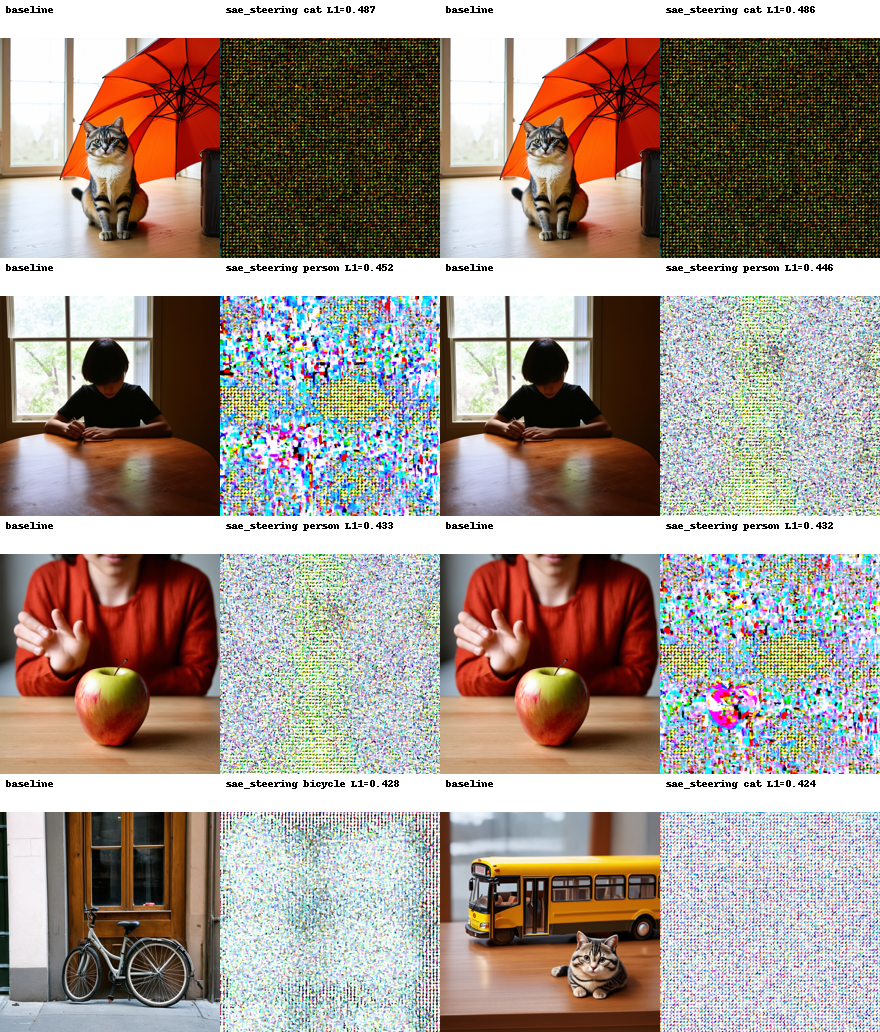

In [18]:
from IPython.display import display as ipy_display

if not diff_df.empty:
    top = diff_df.sort_values("l1_mean", ascending=False).head(8)
    image_paths = []
    titles = []
    for _, row in top.iterrows():
        image_paths.extend([row["baseline_path"], row["edited_path"]])
        titles.extend(["baseline", f"{row['kind']} {row.get('label', '')} L1={row['l1_mean']:.3f}"])
    grid = make_image_grid(image_paths, titles, ncols=4, thumb=(220, 220))
    if grid is not None:
        ipy_display(grid)
else:
    print("No images to show yet.")


## 11. Artifact inventory and final storage check


In [19]:
paths_for_size = [
    ("outputs/run", PROJECT_ROOT / "outputs" / RUN_TAG),
    ("annotations/run", PROJECT_ROOT / "annotations" / RUN_TAG),
    ("hf_home", Path(os.environ["HF_HOME"])),
    ("pip_cache", Path(os.environ["PIP_CACHE_DIR"])),
]
size_rows = []
for label, path in paths_for_size:
    size_rows.append({"component": label, "path": str(path), "GiB": gib(directory_size_bytes(path))})
size_df = pd.DataFrame(size_rows)
display(size_df)
print("Total GiB:", round(size_df["GiB"].sum(), 2))

reports = []
for report_path in [
    CAPTURE_DIR / "report.json",
    MASK_DIR / "report.json",
    DIAG_DIR / "report.json",
    *[SAE_ROOT / name / "report.json" for name in SAE_SPECS],
    *[CONCEPT_ROOT / name / "report.json" for name in SAE_SPECS],
]:
    if report_path.exists():
        data = json.loads(report_path.read_text(encoding="utf-8"))
        reports.append({"report": str(report_path.relative_to(PROJECT_ROOT)), **{k: data.get(k) for k in ["status", "samples", "rows", "labels", "activation_actual_files", "activation_expected_files", "activation_missing_files"]}})

display(pd.DataFrame(reports))


,component,path,GiB
0,outputs/run,/home/jupyter/project/diffusion_attention_anal...,123.045691
1,annotations/run,/home/jupyter/project/diffusion_attention_anal...,0.061806
2,hf_home,/home/jupyter/filestore/container4/hf_home,15.002203
3,pip_cache,/home/jupyter/filestore/container4/pip_cache,0.000000


Total GiB: 138.11


,report,status,samples,rows,labels,activation_actual_files,activation_expected_files,activation_missing_files
0,outputs/sd3_medium_sae_circuit_150/01_capture/...,ok,150.0,NaN,NaN,1350.0,1350.0,0.0
1,annotations/sd3_medium_sae_circuit_150/report....,ok,NaN,NaN,NaN,NaN,NaN,NaN
2,outputs/sd3_medium_sae_circuit_150/02_attentio...,ok,NaN,2700.0,NaN,NaN,NaN,NaN
3,outputs/sd3_medium_sae_circuit_150/03_sae/earl...,ok,NaN,NaN,NaN,NaN,NaN,NaN
4,outputs/sd3_medium_sae_circuit_150/03_sae/mid_...,ok,NaN,NaN,NaN,NaN,NaN,NaN
5,outputs/sd3_medium_sae_circuit_150/03_sae/late...,ok,NaN,NaN,NaN,NaN,NaN,NaN
6,outputs/sd3_medium_sae_circuit_150/04_concept_...,ok,NaN,600.0,30.0,NaN,NaN,NaN
7,outputs/sd3_medium_sae_circuit_150/04_concept_...,ok,NaN,600.0,30.0,NaN,NaN,NaN
8,outputs/sd3_medium_sae_circuit_150/04_concept_...,ok,NaN,600.0,30.0,NaN,NaN,NaN


## 12. Additional analytics

In [8]:
# Extra steering diagnostics: structural similarity, edge preservation,
# high-frequency/noise score, and target-mask locality.

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity as _skimage_ssim
except Exception:
    _skimage_ssim = None

try:
    safe_file_part
except NameError:
    from diffusion_attention_analysis_v2.sd3_notebook_utils import safe_file_part

_RESAMPLE_BILINEAR = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
_RESAMPLE_NEAREST = Image.Resampling.NEAREST if hasattr(Image, "Resampling") else Image.NEAREST
_RESAMPLE_LANCZOS = Image.Resampling.LANCZOS if hasattr(Image, "Resampling") else Image.LANCZOS

EXT_METRIC_SIZE = 256
METRICS_CSV = INTERVENTION_ROOT / "sd3_time_adaptive_diff_metrics.csv"

if METRICS_CSV.exists():
    diff_df = pd.read_csv(METRICS_CSV)
else:
    print("Metric CSV not found, using in-memory diff_df from previous cells.")

def _read_rgb(path, size=EXT_METRIC_SIZE):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size), _RESAMPLE_LANCZOS)
    return np.asarray(img).astype(np.float32) / 255.0

def _gray(x):
    return 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]

def _safe_corr(a, b):
    a = np.asarray(a).reshape(-1).astype(np.float64)
    b = np.asarray(b).reshape(-1).astype(np.float64)
    a = a - a.mean()
    b = b - b.mean()
    denom = np.sqrt((a * a).sum() * (b * b).sum())
    if denom < 1e-12:
        return np.nan
    return float((a * b).sum() / denom)

def _global_ssim_fallback(x, y):
    gx = _gray(x)
    gy = _gray(y)
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mux = gx.mean()
    muy = gy.mean()
    vx = gx.var()
    vy = gy.var()
    cov = ((gx - mux) * (gy - muy)).mean()
    return float(((2 * mux * muy + c1) * (2 * cov + c2)) / ((mux ** 2 + muy ** 2 + c1) * (vx + vy + c2)))

def _ssim(x, y):
    if _skimage_ssim is not None:
        try:
            return float(_skimage_ssim(x, y, channel_axis=2, data_range=1.0))
        except TypeError:
            return float(_skimage_ssim(x, y, multichannel=True, data_range=1.0))
    return _global_ssim_fallback(x, y)

def _gradient_magnitude(g):
    dy = np.diff(g, axis=0, append=g[-1:, :])
    dx = np.diff(g, axis=1, append=g[:, -1:])
    return np.sqrt(dx * dx + dy * dy)

def _total_variation(x):
    dy = np.abs(np.diff(x, axis=0)).mean()
    dx = np.abs(np.diff(x, axis=1)).mean()
    return float(0.5 * (dx + dy))

def _high_frequency_fraction(g):
    g = g.astype(np.float32)
    g = g - g.mean()
    power = np.abs(np.fft.fftshift(np.fft.fft2(g))) ** 2
    total = float(power.sum())
    if total <= 1e-12:
        return np.nan
    h, w = g.shape
    yy, xx = np.ogrid[:h, :w]
    cy, cx = h // 2, w // 2
    rr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    high = rr > 0.35 * rr.max()
    return float(power[high].sum() / total)

def _find_mask_path(row):
    label = row.get("label", None)
    if label is None or pd.isna(label):
        return None
    base_id = str(row.get("base_id", ""))
    if not base_id:
        return None

    sample_dir = MASK_DIR / base_id
    label_s = str(label).strip()
    candidates = [
        sample_dir / f"{safe_file_part(label_s)}.png",
        sample_dir / f"{safe_file_part(label_s.lower())}.png",
        sample_dir / f"{label_s}.png",
        sample_dir / f"{label_s.lower()}.png",
    ]

    manifest_path = sample_dir / "mask_manifest.json"
    if manifest_path.exists():
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
            for item in manifest.get("masks", []):
                if str(item.get("label", "")).lower() == label_s.lower() or str(item.get("token", "")).lower() == label_s.lower():
                    candidates.append(sample_dir / item["file"])
        except Exception:
            pass

    for path in candidates:
        if path.exists():
            return path
    return None

def _load_mask_for_row(row, size=EXT_METRIC_SIZE):
    mask_path = _find_mask_path(row)
    if mask_path is None:
        return None, None
    mask = Image.open(mask_path).convert("L").resize((size, size), _RESAMPLE_NEAREST)
    mask = np.asarray(mask) > 127
    if mask.mean() <= 1e-5 or mask.mean() >= 0.98:
        return None, str(mask_path)
    return mask, str(mask_path)

def _extended_row_metrics(row, size=EXT_METRIC_SIZE):
    x = _read_rgb(row["baseline_path"], size=size)
    y = _read_rgb(row["edited_path"], size=size)

    gx = _gray(x)
    gy = _gray(y)
    diff = np.abs(y - x)
    diff_gray = diff.mean(axis=2)

    mse = float(((y - x) ** 2).mean())
    psnr = float("inf") if mse <= 1e-12 else float(20.0 * np.log10(1.0 / np.sqrt(mse)))

    edge_x = _gradient_magnitude(gx)
    edge_y = _gradient_magnitude(gy)

    tv_x = _total_variation(x)
    tv_y = _total_variation(y)

    hf_x = _high_frequency_fraction(gx)
    hf_y = _high_frequency_fraction(gy)

    out = {
        "psnr": psnr,
        "ssim": _ssim(x, y),
        "edge_corr": _safe_corr(edge_x, edge_y),
        "edge_l1": float(np.abs(edge_y - edge_x).mean()),
        "tv_baseline": tv_x,
        "tv_edited": tv_y,
        "tv_ratio": float(tv_y / max(tv_x, 1e-8)),
        "hf_baseline": hf_x,
        "hf_edited": hf_y,
        "hf_ratio": float(hf_y / max(hf_x, 1e-8)) if np.isfinite(hf_x) and np.isfinite(hf_y) else np.nan,
    }

    mask, mask_path = _load_mask_for_row(row, size=size)
    out["mask_path"] = mask_path
    out["mask_available"] = mask is not None

    if mask is not None:
        inside = mask
        outside = ~mask
        inside_l1 = float(diff_gray[inside].mean()) if inside.any() else np.nan
        outside_l1 = float(diff_gray[outside].mean()) if outside.any() else np.nan
        out.update({
            "inside_l1": inside_l1,
            "outside_l1": outside_l1,
            "locality_ratio": float(inside_l1 / max(outside_l1, 1e-8)) if np.isfinite(inside_l1) and np.isfinite(outside_l1) else np.nan,
            "inside_changed_010": float((diff_gray[inside] > 0.10).mean()) if inside.any() else np.nan,
            "outside_changed_010": float((diff_gray[outside] > 0.10).mean()) if outside.any() else np.nan,
            "mask_coverage": float(mask.mean()),
        })
    else:
        out.update({
            "inside_l1": np.nan,
            "outside_l1": np.nan,
            "locality_ratio": np.nan,
            "inside_changed_010": np.nan,
            "outside_changed_010": np.nan,
            "mask_coverage": np.nan,
        })

    return out

def add_extended_metrics(df, out_csv=None, size=EXT_METRIC_SIZE):
    rows = []
    for _, row in df.iterrows():
        try:
            rows.append(_extended_row_metrics(row, size=size))
        except Exception as exc:
            rows.append({"metrics_error": repr(exc)})

    ext = pd.concat([df.reset_index(drop=True), pd.DataFrame(rows)], axis=1)

    # Original artifact flag plus structure/frequency criteria.
    if "artifact_flag" not in ext.columns:
        ext["artifact_flag"] = False

    ext["structure_artifact"] = (
        ext["artifact_flag"].fillna(False).astype(bool)
        | (ext["changed_px_020"].fillna(0) > 0.70)
        | ((ext["ssim"].fillna(1.0) < 0.20) & (ext["edge_corr"].fillna(1.0) < 0.20))
        | (ext["tv_ratio"].fillna(1.0) > 3.0)
        | (ext["hf_ratio"].fillna(1.0) > 3.0)
    )

    ext["usable_steering"] = (
        ext["kind"].eq("sae_steering")
        & (~ext["structure_artifact"])
        & ext["l1_mean"].between(0.01, 0.25)
        & (ext["ssim"].fillna(0.0) > 0.25)
        & (ext["edge_corr"].fillna(0.0) > 0.25)
        & (ext["changed_px_020"].fillna(1.0) < 0.55)
    )

    ext["localized_steering"] = (
        ext["usable_steering"]
        & ext["mask_available"].fillna(False).astype(bool)
        & (ext["locality_ratio"].fillna(0.0) > 1.15)
        & (ext["outside_l1"].fillna(1.0) < 0.15)
    )

    if out_csv is not None:
        Path(out_csv).parent.mkdir(parents=True, exist_ok=True)
        ext.to_csv(out_csv, index=False)

    return ext

ext_df = add_extended_metrics(
    diff_df,
    out_csv=INTERVENTION_ROOT / "sd3_time_adaptive_extended_metrics.csv",
)

print("rows:", len(ext_df))
display(ext_df.head(10))

rows: 192


,kind,sample_id,base_id,prompt,baseline_path,edited_path,beta,scale,concept_ids,module,sae_name,window,l1_mean,rmse,changed_px_005,changed_px_010,changed_px_020,label,artifact_flag,moderate_change,psnr,ssim,edge_corr,edge_l1,tv_baseline,tv_edited,tv_ratio,hf_baseline,hf_edited,hf_ratio,mask_path,mask_available,inside_l1,outside_l1,locality_ratio,inside_changed_010,outside_changed_010,mask_coverage,structure_artifact,usable_steering,localized_steering
0,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_0.6,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.60,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.261939,0.335220,0.903549,0.772888,0.518967,NaN,False,True,9.447761,0.246615,0.108787,0.083991,0.028153,0.056196,1.996125,0.013428,0.063553,4.732767,None,False,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
1,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_0.75,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.75,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.316425,0.397657,0.950745,0.858444,0.646439,NaN,False,False,7.970038,0.188390,0.132439,0.098119,0.028153,0.070435,2.501894,0.013428,0.061073,4.548106,None,False,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
2,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_1.15,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.15,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.128323,0.203915,0.581467,0.419479,0.205490,NaN,False,True,13.761647,0.551266,0.354476,0.044986,0.028153,0.025032,0.889152,0.013428,0.010643,0.792568,None,False,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
3,block_scaling,sd3_circuit_000_dog_table_seed_0000_scale_1.35,sd3_circuit_000_dog_table_seed_0000,realistic photo of a dog next to a table insid...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.35,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.155710,0.217828,0.692169,0.533646,0.296707,NaN,False,True,13.192193,0.477893,0.360697,0.050246,0.028153,0.028361,1.007390,0.013428,0.016930,1.260748,None,False,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False
4,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_0.6,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.60,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.337169,0.393341,0.981262,0.932220,0.797882,NaN,True,False,8.074802,0.145081,0.061732,0.088753,0.026085,0.057726,2.212994,0.013722,0.090462,6.592275,None,False,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
5,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_0.75,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,0.75,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.404804,0.514242,0.968307,0.918625,0.803024,NaN,True,False,5.768266,0.206035,0.022943,0.057871,0.026085,0.027416,1.051026,0.013722,0.016159,1.177569,None,False,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
6,block_scaling,sd3_circuit_001_cat_umbrella_seed_0000_scale_1.15,sd3_circuit_001_cat_umbrella_seed_0000,documentary photo of a cat near a umbrella ins...,/home/jupyter/project/diffusion_attention_anal...,/home/jupyter/project/diffusion_attention_anal...,NaN,1.15,[],transformer_blocks.0,early_block0_step0,early_block0_step0,0.177244,0.253846,0.818146,0.675537,0.297607,NaN,False,True,11.871041,0.

,kind,window,n,mean_l1,median_l1,mean_ssim,mean_psnr,mean_edge_corr,mean_hf_ratio,mean_tv_ratio,artifact_rate_old,structure_artifact_rate,usable_steering_rate,localized_steering_rate,mean_inside_l1,mean_outside_l1,mean_locality_ratio
0,block_scaling,early_block0_step0,16,0.252012,0.254185,0.343966,9.774782,0.115168,3.212138,1.562774,0.1875,0.4375,0.0,0.0,NaN,NaN,NaN
1,block_scaling,late_block23_step27,16,0.000458,0.000462,0.999197,57.118711,0.999855,0.999987,1.000029,0.0000,0.0000,0.0,0.0,NaN,NaN,NaN
2,block_scaling,mid_block11_step13,16,0.031079,0.025238,0.869584,27.332350,0.875425,1.016096,1.104881,0.0000,0.0000,0.0,0.0,NaN,NaN,NaN
3,sae_steering,early_block0_step0,48,0.272002,0.338557,0.304735,NaN,0.283337,22.294143,5.426702,0.6250,0.7500,0.0,0.0,0.272416,0.272349,0.757255
4,sae_steering,late_block23_step27,48,0.196754,0.182393,0.385904,NaN,0.363809,38.449695,5.840863,0.2500,0.7500,0.0,0.0,0.198069,0.200040,0.752434
5,sae_steering,mid_block11_step13,48,0.257722,0.307453,0.333184,NaN,0.293873,29.285393,4.376196,0.3750,0.7500,0.0,0.0,0.236775,0.263625,0.683753


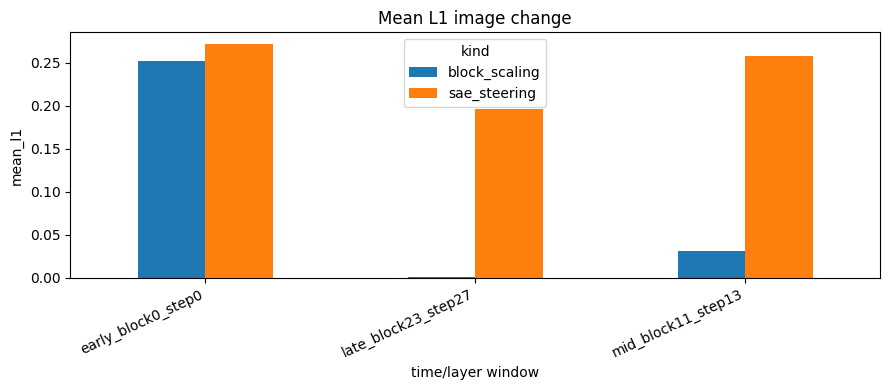

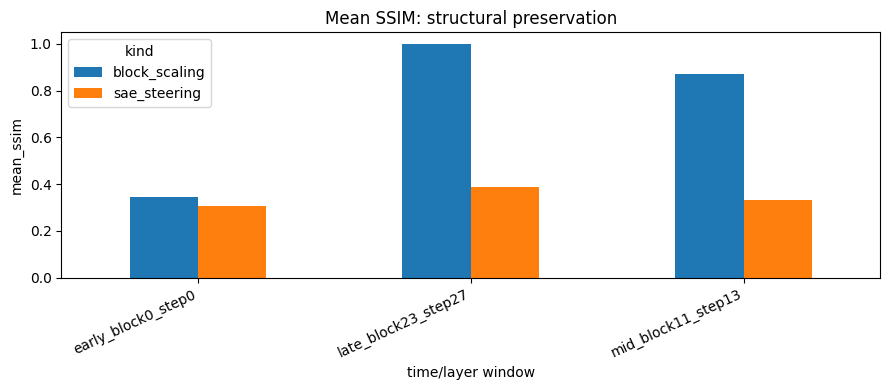

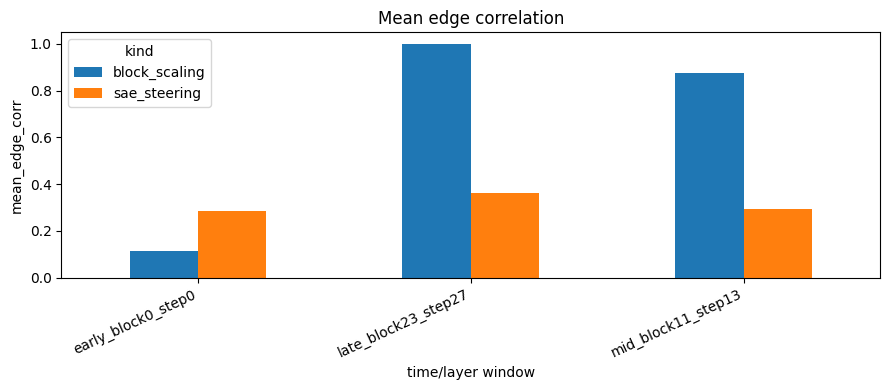

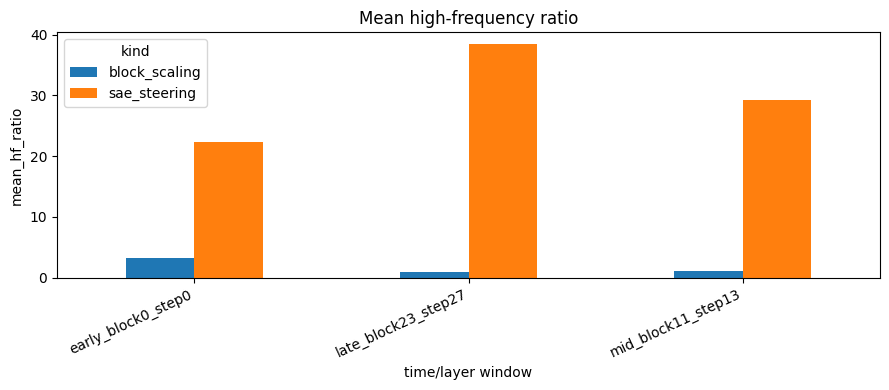

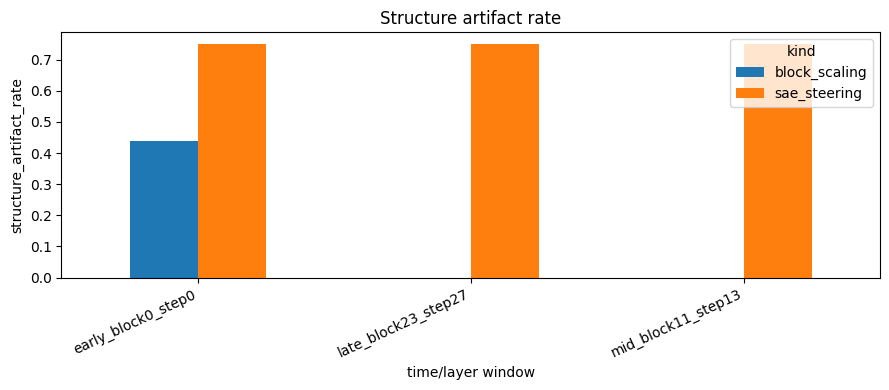

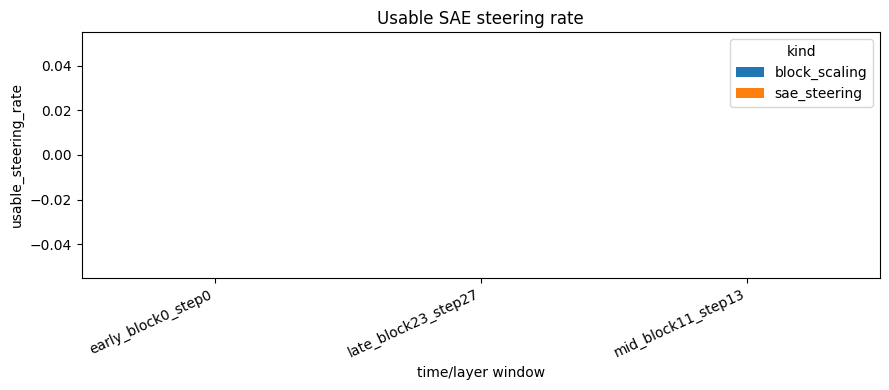

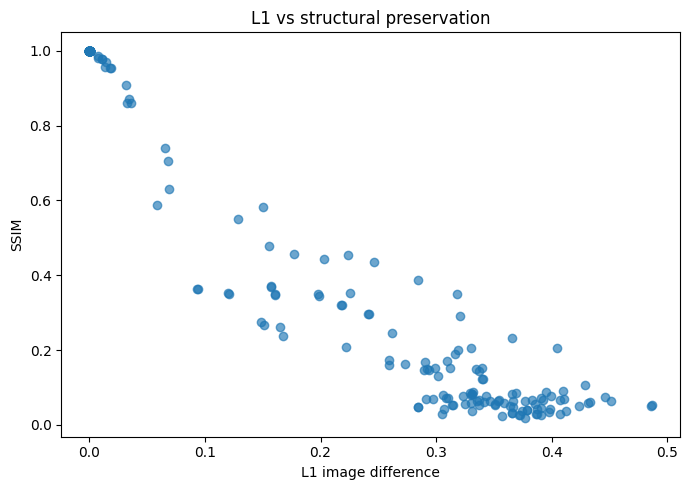

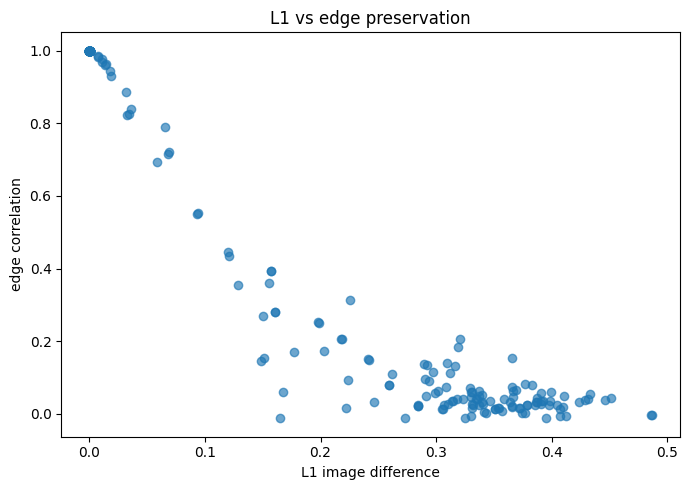

In [9]:
summary_ext = ext_df.groupby(["kind", "window"], as_index=False).agg(
    n=("sample_id", "count"),
    mean_l1=("l1_mean", "mean"),
    median_l1=("l1_mean", "median"),
    mean_ssim=("ssim", "mean"),
    mean_psnr=("psnr", "mean"),
    mean_edge_corr=("edge_corr", "mean"),
    mean_hf_ratio=("hf_ratio", "mean"),
    mean_tv_ratio=("tv_ratio", "mean"),
    artifact_rate_old=("artifact_flag", "mean"),
    structure_artifact_rate=("structure_artifact", "mean"),
    usable_steering_rate=("usable_steering", "mean"),
    localized_steering_rate=("localized_steering", "mean"),
    mean_inside_l1=("inside_l1", "mean"),
    mean_outside_l1=("outside_l1", "mean"),
    mean_locality_ratio=("locality_ratio", "mean"),
)

display(summary_ext)

# Separate plots, one metric per figure.
for metric, title in [
    ("mean_l1", "Mean L1 image change"),
    ("mean_ssim", "Mean SSIM: structural preservation"),
    ("mean_edge_corr", "Mean edge correlation"),
    ("mean_hf_ratio", "Mean high-frequency ratio"),
    ("structure_artifact_rate", "Structure artifact rate"),
    ("usable_steering_rate", "Usable SAE steering rate"),
]:
    plot_df = summary_ext.pivot(index="window", columns="kind", values=metric)
    ax = plot_df.plot(kind="bar", figsize=(9, 4))
    ax.set_title(title)
    ax.set_xlabel("time/layer window")
    ax.set_ylabel(metric)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

# L1 alone is misleading: this scatter separates large meaningful change from collapse.
plot_df = ext_df.copy()
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df["l1_mean"], plot_df["ssim"], alpha=0.65)
ax.set_xlabel("L1 image difference")
ax.set_ylabel("SSIM")
ax.set_title("L1 vs structural preservation")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(plot_df["l1_mean"], plot_df["edge_corr"], alpha=0.65)
ax.set_xlabel("L1 image difference")
ax.set_ylabel("edge correlation")
ax.set_title("L1 vs edge preservation")
plt.tight_layout()
plt.show()

,window,label,beta,n,mean_l1,mean_ssim,mean_edge_corr,mean_hf_ratio,structure_artifact_rate,usable_steering_rate,mean_inside_l1,mean_outside_l1,mean_locality_ratio
0,early_block0_step0,bicycle,-40.0,2,0.358200,0.064672,0.057252,9.594287,1.0,0.0,0.297342,0.376105,0.796244
1,early_block0_step0,bicycle,0.0,2,0.000000,1.000000,1.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000
2,early_block0_step0,bicycle,40.0,2,0.351601,0.067914,0.061143,6.961403,1.0,0.0,0.393658,0.347368,1.131261
3,early_block0_step0,bicycle,60.0,2,0.349740,0.071132,0.055730,7.521470,1.0,0.0,0.394784,0.344672,1.142948
4,early_block0_step0,book,-40.0,2,0.363327,0.053617,0.048096,28.091647,1.0,0.0,0.334710,0.370122,0.910411
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,mid_block11_step13,dog,60.0,2,0.291224,0.208854,0.088360,28.279777,1.0,0.0,0.237196,0.302516,0.817815
68,mid_block11_step13,person,-40.0,2,0.439607,0.068916,0.044910,101.846158,1.0,0.0,0.572713,0.385200,1.485574
69,mid_block11_step13,person,0.0,2,0.000000,1.000000,1.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000
70,mid_block11_step13,person,40.0,2,0.274821,0.171254,0.087451,40.951417,1.0,0.0,0.173535,0.316100,0.549069


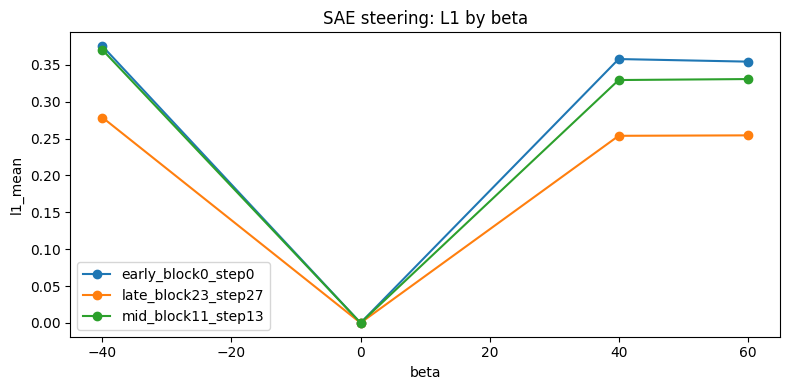

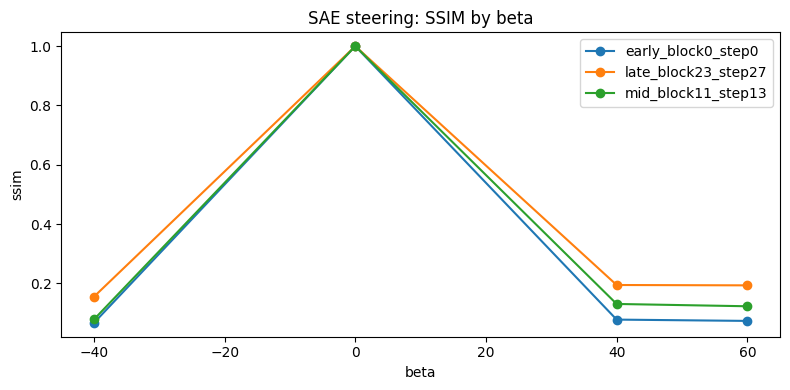

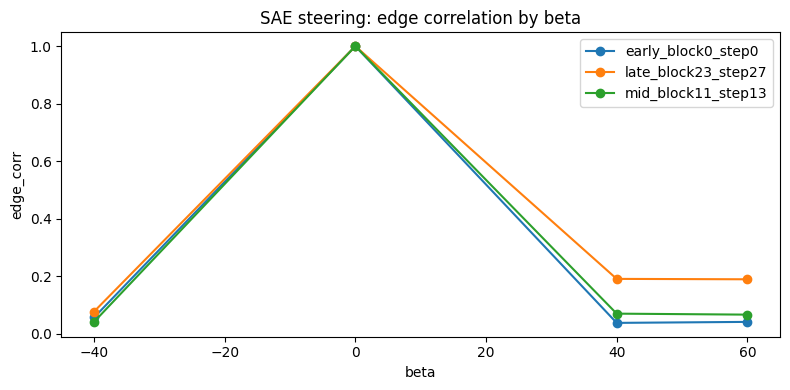

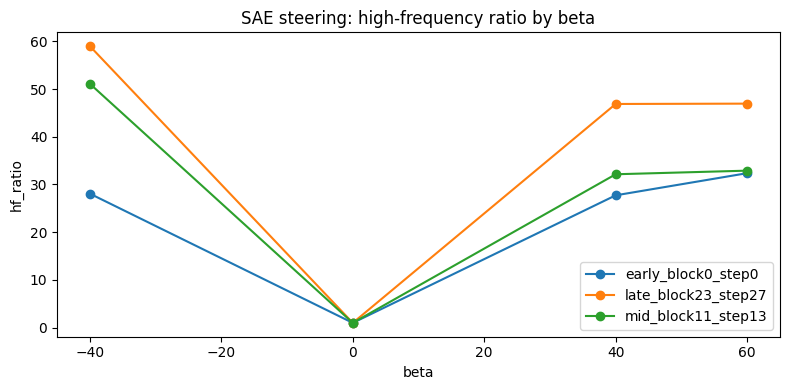

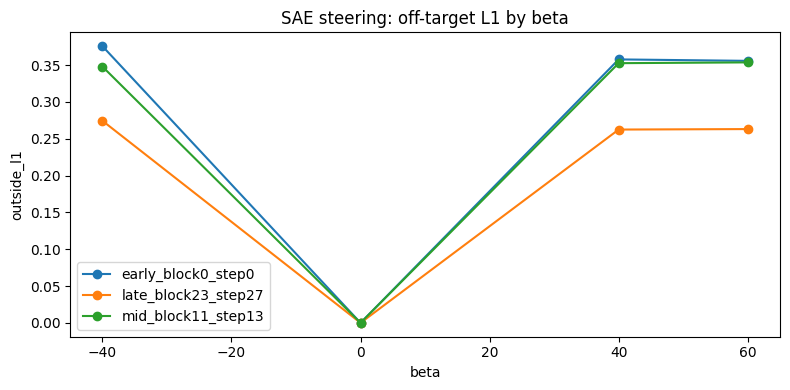

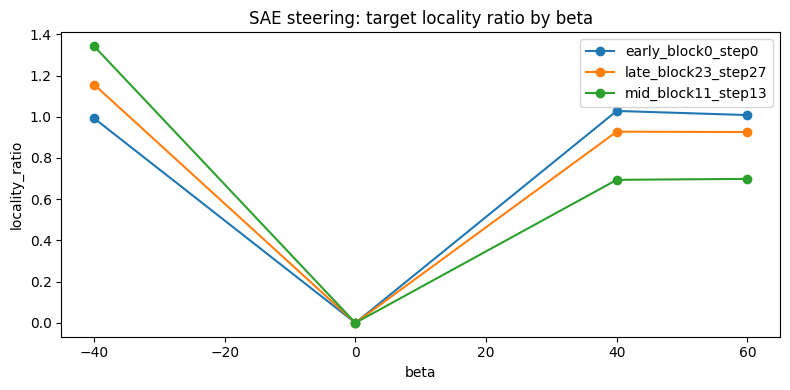

In [10]:
sae_ext = ext_df[ext_df["kind"].eq("sae_steering")].copy()

beta_summary = sae_ext.groupby(["window", "label", "beta"], as_index=False).agg(
    n=("sample_id", "count"),
    mean_l1=("l1_mean", "mean"),
    mean_ssim=("ssim", "mean"),
    mean_edge_corr=("edge_corr", "mean"),
    mean_hf_ratio=("hf_ratio", "mean"),
    structure_artifact_rate=("structure_artifact", "mean"),
    usable_steering_rate=("usable_steering", "mean"),
    mean_inside_l1=("inside_l1", "mean"),
    mean_outside_l1=("outside_l1", "mean"),
    mean_locality_ratio=("locality_ratio", "mean"),
)

display(beta_summary.sort_values(["window", "label", "beta"]))

for metric, title in [
    ("l1_mean", "SAE steering: L1 by beta"),
    ("ssim", "SAE steering: SSIM by beta"),
    ("edge_corr", "SAE steering: edge correlation by beta"),
    ("hf_ratio", "SAE steering: high-frequency ratio by beta"),
    ("outside_l1", "SAE steering: off-target L1 by beta"),
    ("locality_ratio", "SAE steering: target locality ratio by beta"),
]:
    curve = sae_ext.groupby(["window", "beta"], as_index=False)[metric].mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    for window, sub in curve.groupby("window"):
        sub = sub.sort_values("beta")
        ax.plot(sub["beta"], sub[metric], marker="o", label=window)
    ax.set_title(title)
    ax.set_xlabel("beta")
    ax.set_ylabel(metric)
    ax.legend()
    plt.tight_layout()
    plt.show()

No usable SAE steering candidates under current thresholds. This confirms that the current beta/window setting is too destructive.


,window,label,beta,l1_mean,ssim,edge_corr,hf_ratio,tv_ratio,changed_px_020,prompt
88,early_block0_step0,person,-40.0,0.431507,0.057297,0.041379,69.569982,9.145774,0.874222,studio photo of a person in front of a apple o...
184,late_block23_step27,person,-40.0,0.407048,0.029754,0.013613,187.392895,14.467160,0.866745,studio photo of a person in front of a apple o...
136,mid_block11_step13,person,-40.0,0.433016,0.062275,0.052982,117.105587,9.525636,0.831100,studio photo of a person in front of a apple o...
51,early_block0_step0,dog,60.0,0.382958,0.066481,0.080180,31.177387,6.593118,0.823547,realistic photo of a dog next to a table insid...
92,early_block0_step0,person,-40.0,0.451504,0.063157,0.044243,45.856484,7.984121,0.821198,natural light photo of a window behind a perso...
108,mid_block11_step13,cat,-40.0,0.423855,0.051098,0.031327,28.744388,6.340723,0.819839,realistic photo of a bus beside a cat on a woo...
135,mid_block11_step13,bicycle,60.0,0.410642,0.070067,0.048140,6.669332,4.684336,0.818329,realistic photo of a lamp near a bicycle insid...
50,early_block0_step0,dog,40.0,0.377131,0.064169,0.081931,32.904086,6.597031,0.817535,realistic photo of a dog next to a table insid...
134,mid_block11_step13,bicycle,40.0,0.399447,0.076231,0.058961,5.554594,4.418345,0.815018,realistic photo of a lamp near a bicycle insid...
107,mid_block11_step13,cat,60.0,0.486014,0.050802,-0.004192,61.876142,4.770537,0.813309,documentary photo of a cat near a umbrella ins...


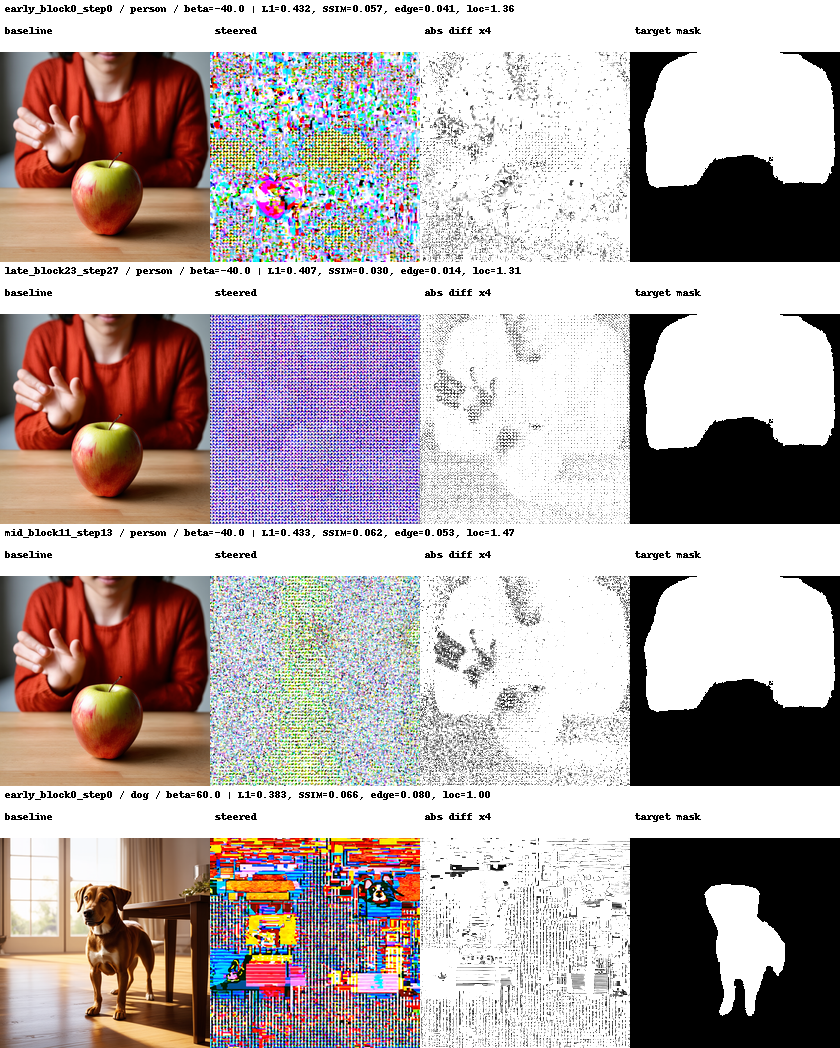

In [11]:
def _fit_thumb(img, thumb):
    img = img.copy()
    img.thumbnail(thumb, _RESAMPLE_LANCZOS)
    canvas = Image.new("RGB", thumb, "white")
    canvas.paste(img, ((thumb[0] - img.width) // 2, (thumb[1] - img.height) // 2))
    return canvas

def _diff_thumb(row, thumb=(210, 210), gain=4.0):
    x = _read_rgb(row["baseline_path"], size=thumb[0])
    y = _read_rgb(row["edited_path"], size=thumb[0])
    d = np.abs(y - x).mean(axis=2)
    d = np.clip(d * gain, 0, 1)
    img = Image.fromarray((d * 255).astype(np.uint8)).convert("RGB")
    return _fit_thumb(img, thumb)

def _mask_thumb(row, thumb=(210, 210)):
    mask, _ = _load_mask_for_row(row, size=thumb[0])
    if mask is None:
        img = Image.new("RGB", thumb, "white")
        draw = ImageDraw.Draw(img)
        draw.text((10, 10), "no target mask", fill=(0, 0, 0))
        return img
    img = Image.fromarray((mask.astype(np.uint8) * 255)).convert("RGB")
    return _fit_thumb(img, thumb)

def make_steering_quad_grid(rows_df, *, max_rows=6, thumb=(210, 210), title_h=52):
    rows_df = rows_df.head(max_rows).copy()
    if rows_df.empty:
        return None

    ncols = 4
    nrows = len(rows_df)
    canvas = Image.new("RGB", (ncols * thumb[0], nrows * (thumb[1] + title_h)), "white")
    draw = ImageDraw.Draw(canvas)

    col_titles = ["baseline", "steered", "abs diff x4", "target mask"]
    for r_idx, (_, row) in enumerate(rows_df.iterrows()):
        y0 = r_idx * (thumb[1] + title_h)

        title = (
            f"{row.get('window','')} / {row.get('label','')} / beta={row.get('beta', np.nan)} | "
            f"L1={row.get('l1_mean', np.nan):.3f}, SSIM={row.get('ssim', np.nan):.3f}, "
            f"edge={row.get('edge_corr', np.nan):.3f}, loc={row.get('locality_ratio', np.nan):.2f}"
        )
        draw.text((5, y0 + 3), title[:150], fill=(0, 0, 0))

        imgs = [
            _fit_thumb(Image.open(row["baseline_path"]).convert("RGB"), thumb),
            _fit_thumb(Image.open(row["edited_path"]).convert("RGB"), thumb),
            _diff_thumb(row, thumb=thumb, gain=4.0),
            _mask_thumb(row, thumb=thumb),
        ]

        for c_idx, img in enumerate(imgs):
            x0 = c_idx * thumb[0]
            draw.text((x0 + 5, y0 + 25), col_titles[c_idx], fill=(0, 0, 0))
            canvas.paste(img, (x0, y0 + title_h))

    return canvas

# Score favors visible but structurally preserved and localized changes.
safe_candidates = ext_df[
    ext_df["kind"].eq("sae_steering")
    & ext_df["usable_steering"]
].copy()

if not safe_candidates.empty:
    safe_candidates["candidate_score"] = (
        safe_candidates["l1_mean"].clip(0, 0.25)
        * safe_candidates["ssim"].clip(0, 1)
        * safe_candidates["edge_corr"].clip(0, 1)
        * safe_candidates["locality_ratio"].fillna(1).clip(0, 5)
        / (1.0 + np.maximum(0.0, np.log(safe_candidates["hf_ratio"].fillna(1).clip(1e-6))))
    )
    safe_candidates = safe_candidates.sort_values("candidate_score", ascending=False)
    display(safe_candidates[[
        "kind", "window", "label", "beta", "l1_mean", "ssim", "edge_corr",
        "hf_ratio", "tv_ratio", "inside_l1", "outside_l1", "locality_ratio",
        "structure_artifact", "prompt"
    ]].head(12))

    grid = make_steering_quad_grid(safe_candidates, max_rows=6)
    if grid is not None:
        display(grid)
else:
    print("No usable SAE steering candidates under current thresholds. This confirms that the current beta/window setting is too destructive.")

# Also show failure cases explicitly, but now labeled as failure modes.
failure_cases = ext_df[
    ext_df["kind"].eq("sae_steering")
    & ext_df["structure_artifact"]
].sort_values(["changed_px_020", "l1_mean"], ascending=False)

display(failure_cases[[
    "window", "label", "beta", "l1_mean", "ssim", "edge_corr",
    "hf_ratio", "tv_ratio", "changed_px_020", "prompt"
]].head(12))

failure_grid = make_steering_quad_grid(failure_cases, max_rows=4)
if failure_grid is not None:
    display(failure_grid)

## 13 (5b) Steering repeat

In [7]:
SAE_STEER_CFG = "configs/05_interventions/sd3_medium_time_adaptive_sae_steering.yaml"
baseline_samples = CAPTURE_DIR / "samples"

print("SAE_STEER_CFG:", SAE_STEER_CFG)
print("baseline_samples:", baseline_samples, "exists:", baseline_samples.exists())
print("SAE_ROOT:", SAE_ROOT, "exists:", SAE_ROOT.exists())
print("CONCEPT_ROOT:", CONCEPT_ROOT, "exists:", CONCEPT_ROOT.exists())
print("INTERVENTION_ROOT:", INTERVENTION_ROOT, "exists:", INTERVENTION_ROOT.exists())

SAE_STEER_CFG: configs/05_interventions/sd3_medium_time_adaptive_sae_steering.yaml
baseline_samples: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/01_capture/samples exists: True
SAE_ROOT: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/03_sae exists: True
CONCEPT_ROOT: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/04_concept_dictionary exists: True
INTERVENTION_ROOT: /home/jupyter/project/diffusion_attention_analysis_2/outputs/sd3_medium_sae_circuit_150/05_interventions exists: True


In [ ]:
# safer SAE steering rerun


RUN_SAFE_SAE_STEERING = True

SAFE_STEER_NAME = "sae_steering_safe_anchor_v1"
SAFE_STEER_ROOT = INTERVENTION_ROOT / SAFE_STEER_NAME

SAFE_TARGET_LABELS = TARGET_LABELS
SAFE_PROMPTS_PER_LABEL = 2
SAFE_BETAS = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20, 0.40]
SAFE_ACTIVE_QUANTILE = 0.95
SAFE_MAX_REUSE = 8
SAFE_FEATURES_PER_LABEL = 2

def strict_select_features_for_labels(concept_csv, labels, *, per_label=2, max_reuse=8, min_score=0.0):
    df = feature_specificity(concept_csv)
    out = {}
    for label in labels:
        sub = df[
            (df["label"].astype(str).str.lower() == label.lower())
            & (df["score"] >= min_score)
            & (df["reuse_count"] <= max_reuse)
        ].copy()
        if sub.empty:
            out[label] = []
            continue
        out[label] = [
            int(x)
            for x in sub.sort_values("specificity_score", ascending=False)["feature_id"].head(per_label)
        ]
    return out

safe_selection = {}
for name in SAE_SPECS:
    csv_path = CONCEPT_ROOT / name / "concept_dictionary.csv"
    if csv_path.exists():
        safe_selection[name] = strict_select_features_for_labels(
            csv_path,
            SAFE_TARGET_LABELS,
            per_label=SAFE_FEATURES_PER_LABEL,
            max_reuse=SAFE_MAX_REUSE,
            min_score=0.0,
        )

print(json.dumps(safe_selection, indent=2, ensure_ascii=False))

safe_probe_paths = write_label_probe_prompts(
    PROMPTS_PATH,
    PROBE_PROMPT_ROOT / "safe_anchor_v1",
    SAFE_TARGET_LABELS,
    prompts_per_label=SAFE_PROMPTS_PER_LABEL,
)

safe_reports = []
if RUN_SAFE_SAE_STEERING:
    for name, spec in SAE_SPECS.items():
        sae_path = SAE_ROOT / name / "sae.pt"
        label_to_ids = safe_selection.get(name, {})

        for label in SAFE_TARGET_LABELS:
            concept_ids = label_to_ids.get(label, [])
            prompt_path = safe_probe_paths.get(label)

            if not concept_ids or not prompt_path:
                print(f"[skip] safe {name}/{label}: concept_ids={concept_ids}, prompt_path={prompt_path}")
                continue

            out_dir = SAFE_STEER_ROOT / name / safe_file_part(label)
            beta_list = "[" + ",".join(str(x) for x in SAFE_BETAS) + "]"

            overrides = [
                f"data.prompts_path={prompt_path}",
                f"data.sae_checkpoint={sae_path}",
                f"data.output_dir={out_dir}",
                f"data.max_prompts={SAFE_PROMPTS_PER_LABEL}",
                f"intervention.module={spec['layer']}",

                # Anchor-only intervention: avoids accumulation across 5 denoising steps
                f"intervention.target_steps=[{int(spec['step'])}]",

                f"intervention.concept_ids={concept_ids}",
                f"intervention.betas={beta_list}",
                "intervention.branch_mode=cond",
                "intervention.direction_mode=mean_decoder_direction",
                "intervention.spatial_mode=active_tokens",
                f"intervention.active_quantile={SAFE_ACTIVE_QUANTILE}",
                "intervention.outside_scale=0.0",
                "intervention.normalize_direction=rms",
                "intervention.beta_scale_mode=activation_rms",

                # This key is used only if you apply the small code guard below
                "intervention.max_delta_rms_ratio=0.12",
            ]

            print(f"\n=== SAFE SAE steering {name}/{label}: ids={concept_ids}, step={spec['step']} ===")
            if DRY_RUN_FIRST:
                run_config(SAE_STEER_CFG, overrides=overrides, dry_run=True)
            report = run_config(SAE_STEER_CFG, overrides=overrides, dry_run=False)
            safe_reports.append({
                "run": SAFE_STEER_NAME,
                "sae_name": name,
                "label": label,
                "concept_ids": concept_ids,
                "out_dir": str(out_dir),
                **spec,
                **(report or {}),
            })

    display(pd.DataFrame(safe_reports))
else:
    print("RUN_SAFE_SAE_STEERING is False. Set it to True when ready.")

,kind,window,n,mean_l1,median_l1,mean_ssim,mean_edge_corr,mean_hf_ratio,structure_artifact_rate,usable_steering_rate,localized_steering_rate,mean_inside_l1,mean_outside_l1,mean_locality_ratio
0,sae_steering,early_block0_step0,96,0.113051,0.111308,0.645177,0.491396,1.043630,0.020833,0.729167,0.468750,0.149234,0.105566,1.385296
1,sae_steering,late_block23_step27,48,0.000244,0.000160,0.999517,0.999819,1.000350,0.000000,0.000000,0.000000,0.000307,0.000278,1.219425
2,sae_steering,mid_block11_step13,96,0.007156,0.003769,0.985218,0.982040,0.986372,0.000000,0.270833,0.229167,0.011541,0.006786,1.521870


,window,label,beta,l1_mean,ssim,edge_corr,hf_ratio,inside_l1,outside_l1,locality_ratio,structure_artifact,prompt
13,early_block0_step0,dog,0.10,0.068455,0.821244,0.822419,1.096028,0.174558,0.066263,2.634334,False,studio photo of a tree near a dog on a city st...
12,early_block0_step0,dog,0.05,0.044908,0.875021,0.857682,1.058849,0.148539,0.042743,3.475199,False,studio photo of a tree near a dog on a city st...
15,early_block0_step0,dog,0.40,0.088779,0.781107,0.781951,0.985336,0.170200,0.087231,1.951134,False,studio photo of a tree near a dog on a city st...
14,early_block0_step0,dog,0.20,0.088779,0.781107,0.781951,0.985336,0.170200,0.087231,1.951134,False,studio photo of a tree near a dog on a city st...
76,early_block0_step0,bicycle,0.05,0.052085,0.819192,0.746965,0.702405,0.120523,0.038089,3.164236,False,realistic photo of a lamp near a bicycle insid...
10,early_block0_step0,dog,-0.05,0.114438,0.684952,0.655934,1.041843,0.221506,0.112219,1.973881,False,studio photo of a tree near a dog on a city st...
68,early_block0_step0,bicycle,0.05,0.056182,0.789949,0.697846,1.043492,0.128844,0.042458,3.034627,False,documentary photo of a bicycle next to a windo...
4,early_block0_step0,dog,0.05,0.057803,0.760097,0.621905,1.077119,0.151506,0.043317,3.497589,False,realistic photo of a dog next to a table insid...
82,early_block0_step0,person,-0.05,0.073357,0.704594,0.596419,0.692503,0.108525,0.040262,2.695478,False,studio photo of a person in front of a apple o...
69,early_block0_step0,bicycle,0.10,0.104770,0.610208,0.522559,0.940465,0.204171,0.085500,2.387957,False,documentary photo of a bicycle next to a windo...


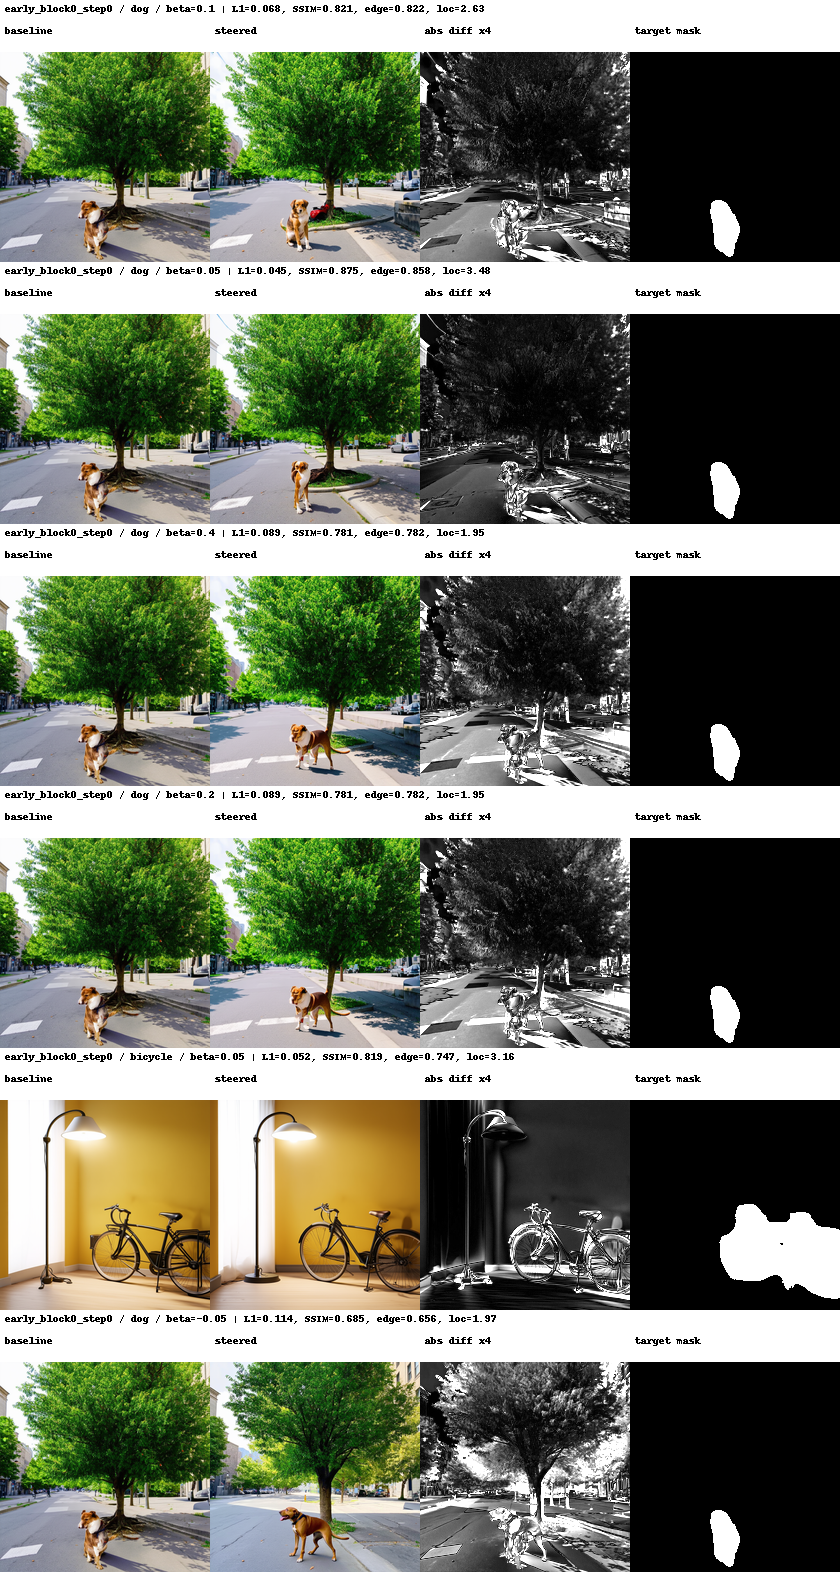

In [14]:
safe_diff_tables = []

for name in SAE_SPECS:
    for label in SAFE_TARGET_LABELS:
        stage_dir = SAFE_STEER_ROOT / name / safe_file_part(label)
        safe_diff_tables.append(collect_intervention_diffs(
            stage_dir,
            baseline_samples,
            image_name="steered.png",
            kind="sae_steering",
            extra={
                "run": SAFE_STEER_NAME,
                "sae_name": name,
                "window": name,
                "label": label,
            },
        ))

safe_diff_df = (
    pd.concat([d for d in safe_diff_tables if d is not None and not d.empty], ignore_index=True)
    if any(d is not None and not d.empty for d in safe_diff_tables)
    else pd.DataFrame()
)

if safe_diff_df.empty:
    print("No safe-run metrics found yet. Run the previous cell with RUN_SAFE_SAE_STEERING=True.")
else:
    safe_ext_df = add_extended_metrics(
        safe_diff_df,
        out_csv=INTERVENTION_ROOT / f"{SAFE_STEER_NAME}_extended_metrics.csv",
    )

    safe_summary = safe_ext_df.groupby(["kind", "window"], as_index=False).agg(
        n=("sample_id", "count"),
        mean_l1=("l1_mean", "mean"),
        median_l1=("l1_mean", "median"),
        mean_ssim=("ssim", "mean"),
        mean_edge_corr=("edge_corr", "mean"),
        mean_hf_ratio=("hf_ratio", "mean"),
        structure_artifact_rate=("structure_artifact", "mean"),
        usable_steering_rate=("usable_steering", "mean"),
        localized_steering_rate=("localized_steering", "mean"),
        mean_inside_l1=("inside_l1", "mean"),
        mean_outside_l1=("outside_l1", "mean"),
        mean_locality_ratio=("locality_ratio", "mean"),
    )

    display(safe_summary)

    safe_candidates = safe_ext_df[
        safe_ext_df["kind"].eq("sae_steering")
        & safe_ext_df["usable_steering"]
    ].copy()

    if not safe_candidates.empty:
        safe_candidates["candidate_score"] = (
            safe_candidates["l1_mean"].clip(0, 0.25)
            * safe_candidates["ssim"].clip(0, 1)
            * safe_candidates["edge_corr"].clip(0, 1)
            * safe_candidates["locality_ratio"].fillna(1).clip(0, 5)
            / (1.0 + np.maximum(0.0, np.log(safe_candidates["hf_ratio"].fillna(1).clip(1e-6))))
        )
        safe_candidates = safe_candidates.sort_values("candidate_score", ascending=False)

        display(safe_candidates[[
            "window", "label", "beta", "l1_mean", "ssim", "edge_corr",
            "hf_ratio", "inside_l1", "outside_l1", "locality_ratio",
            "structure_artifact", "prompt"
        ]].head(12))

        grid = make_steering_quad_grid(safe_candidates, max_rows=6)
        if grid is not None:
            display(grid)
    else:
        print("Safe rerun produced no usable steering candidates under the current thresholds.")